In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from category_encoders import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted


## Data Import

In [10]:
df = pd.read_csv(r"C:\Users\HP\Desktop\PORTFOLIO\In progress\PCOS\PCOS_data_without_infertility - Copy.csv", encoding = 'latin1')
df.head(10)

,ï»¿Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
0,1.0,1.0,0.0,28.0,44.6,152.0,19.3,15.0,78.0,22.0,...,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5,NaN
1,2.0,2.0,0.0,36.0,65.0,161.5,#NAME?,15.0,74.0,20.0,...,0.0,0.0,120.0,70.0,3.0,5.0,15.0,14.0,3.7,NaN
2,3.0,3.0,1.0,33.0,68.8,165.0,#NAME?,11.0,72.0,18.0,...,1.0,0.0,120.0,80.0,13.0,15.0,18.0,20.0,10.0,NaN
3,4.0,4.0,0.0,37.0,65.0,148.0,#NAME?,13.0,72.0,20.0,...,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5,NaN
4,5.0,5.0,0.0,25.0,52.0,161.0,#NAME?,11.0,72.0,18.0,...,0.0,0.0,120.0,80.0,3.0,4.0,16.0,14.0,7.0,NaN
5,6.0,6.0,0.0,36.0,74.1,165.0,#NAME?,15.0,78.0,28.0,...,0.0,0.0,110.0,70.0,9.0,6.0,16.0,20.0,8.0,NaN
6,7.0,7.0,0.0,34.0,64.0,156.0,#NAME?,11.0,72.0,18.0,...,0.0,0.0,120.0,80.0,6.0,6.0,15.0,16.0,6.8,NaN
7,8.0,8.0,0.0,33.0,58.5,159.0,#NAME?,13.0,72.0,20.0,...,0.0,0.0,120.0,80.0,7.0,6.0,15.0,18.0,7.1,NaN
8,9.0,9.0,0.0,32.0,40.0,158.0,#NAME?,11.0,72.0,18.0,...,0.0,0.0,120.0,80.0,5.0,7.0,17.0,17.0,4.2,NaN
9,10.0,10.0,0.0,36.0,52.0,150.0,#NAME?,15.0,80.0,20.0,...,0.0,0.0,110.0,80.0,1.0,1.0,14.0,17.0,2.5,NaN


## Data Exploration

#### Check for the size of dataset and information about the dataset

In [11]:
print(df.shape)
print(df.info())

(999, 45)
<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 45 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ï»¿Sl. No               541 non-null    float64
 1   Patient File No.        541 non-null    float64
 2   PCOS (Y/N)              541 non-null    float64
 3    Age (yrs)              541 non-null    float64
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   BMI                     541 non-null    str    
 7   Blood Group             541 non-null    float64
 8   Pulse rate(bpm)         541 non-null    float64
 9   RR (breaths/min)        541 non-null    float64
 10  Hb(g/dl)                541 non-null    float64
 11  Cycle(R/I)              541 non-null    float64
 12  Cycle length(days)      541 non-null    float64
 13  Marraige Status (Yrs)   540 non-null    float64
 14  Pregnant(Y/N)           541 non-null    flo

Check for null values and remove from Dataset

In [12]:
df.isnull().sum()
df.dropna()

,ï»¿Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Unnamed: 44
180,181.0,181.0,1.0,30.0,70.0,150.0,#NAME?,16.0,74.0,18.0,...,1.0,0.0,120.0,80.0,8.0,6.0,12.0,11.0,4.5,.
363,364.0,364.0,0.0,31.0,48.0,152.0,20.8,17.0,72.0,18.0,...,1.0,0.0,110.0,80.0,1.0,3.0,13.0,13.0,7.0,7


Remove columns that are 'object' type instead of 'float' type.

In [13]:
df.drop(columns = ['BMI','FSH/LH','Waist:Hip Ratio','Unnamed: 44'], inplace=True)
df.head()

,ï»¿Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),...,Pimples(Y/N),Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
0,1.0,1.0,0.0,28.0,44.6,152.0,15.0,78.0,22.0,10.48,...,0.0,1.0,0.0,110.0,80.0,3.0,3.0,18.0,18.0,8.5
1,2.0,2.0,0.0,36.0,65.0,161.5,15.0,74.0,20.0,11.70,...,0.0,0.0,0.0,120.0,70.0,3.0,5.0,15.0,14.0,3.7
2,3.0,3.0,1.0,33.0,68.8,165.0,11.0,72.0,18.0,11.80,...,1.0,1.0,0.0,120.0,80.0,13.0,15.0,18.0,20.0,10.0
3,4.0,4.0,0.0,37.0,65.0,148.0,13.0,72.0,20.0,12.00,...,0.0,0.0,0.0,120.0,70.0,2.0,2.0,15.0,14.0,7.5
4,5.0,5.0,0.0,25.0,52.0,161.0,11.0,72.0,18.0,10.00,...,0.0,0.0,0.0,120.0,80.0,3.0,4.0,16.0,14.0,7.0


In [14]:
df.columns = df.columns.str.strip()  # Removes leading/trailing spaces

In [15]:
# Create new columns to replace the deleted columns


df['BMI']=df['Weight (Kg)']/(df['Height(Cm)']/100)**2
df['FSH/LH']=df['FSH(mIU/mL)']/df['LH(mIU/mL)']
df['Waist:Hip Ratio']=df['Waist(inch)']/df['Hip(inch)']


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 44 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ï»¿Sl. No               541 non-null    float64
 1   Patient File No.        541 non-null    float64
 2   PCOS (Y/N)              541 non-null    float64
 3   Age (yrs)               541 non-null    float64
 4   Weight (Kg)             541 non-null    float64
 5   Height(Cm)              541 non-null    float64
 6   Blood Group             541 non-null    float64
 7   Pulse rate(bpm)         541 non-null    float64
 8   RR (breaths/min)        541 non-null    float64
 9   Hb(g/dl)                541 non-null    float64
 10  Cycle(R/I)              541 non-null    float64
 11  Cycle length(days)      541 non-null    float64
 12  Marraige Status (Yrs)   540 non-null    float64
 13  Pregnant(Y/N)           541 non-null    float64
 14  No. of aborptions       541 non-null    float64
 15  

Converting 'object' to numeric datatype for Exploration and data cleaning

In [17]:
df['II    beta-HCG(mIU/mL)'] = pd.to_numeric(df['II    beta-HCG(mIU/mL)'], errors='coerce')
df['AMH(ng/mL)'] = pd.to_numeric(df['AMH(ng/mL)'], errors='coerce')

In [18]:
##Exploration 
df.corr()

,ï»¿Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),Blood Group,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),...,BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),BMI,FSH/LH,Waist:Hip Ratio
ï»¿Sl. No,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,0.001705,-0.044533,-0.015196,-0.088681,...,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219,-0.081934,0.014279,0.543804
Patient File No.,1.000000,1.000000,0.060998,0.067133,-0.082823,-0.011700,0.001705,-0.044533,-0.015196,-0.088681,...,0.013399,0.009798,0.049658,0.086969,0.289706,0.244608,0.027219,-0.081934,0.014279,0.543804
PCOS (Y/N),0.060998,0.060998,1.000000,-0.168513,0.211938,0.068254,0.036433,0.091821,0.036928,0.087170,...,0.007942,0.038032,0.603346,0.648327,0.132992,0.097690,0.106648,0.200176,-0.018335,0.012414
Age (yrs),0.067133,0.067133,-0.168513,1.000000,-0.029734,-0.119819,-0.010954,0.045831,0.087382,-0.021558,...,0.073587,0.066788,-0.110793,-0.159395,-0.016352,-0.079250,-0.104238,0.018918,0.012463,0.068362
Weight (Kg),-0.082823,-0.082823,0.211938,-0.029734,1.000000,0.420098,0.072682,0.019983,0.043614,0.009594,...,0.027608,0.131402,0.173751,0.124290,-0.021368,-0.073207,-0.010100,0.902205,-0.004845,0.014213
Height(Cm),-0.011700,-0.011700,0.068254,-0.119819,0.420098,1.000000,0.040825,-0.074339,-0.029459,0.024378,...,-0.067959,0.011116,0.106189,0.075358,-0.026705,0.059426,-0.054035,-0.006224,0.022020,-0.010498
Blood Group,0.001705,0.001705,0.036433,-0.010954,0.072682,0.040825,1.000000,0.047572,-0.023766,-0.001759,...,0.030898,0.054014,0.061332,0.013974,-0.035667,-0.015725,-0.015335,0.060230,0.036278,0.015793
Pulse rate(bpm),-0.044533,-0.044533,0.091821,0.045831,0.019983,-0.074339,0.047572,1.000000,0.303804,-0.052048,...,-0.025510,0.007623,0.040390,0.049182,-0.048356,-0.034202,-0.041241,0.050717,-0.013096,-0.052484
RR (breaths/min),-0.015196,-0.015196,0.036928,0.087382,0.043614,-0.029459,-0.023766,0.303804,1.000000,-0.040487,...,0.017323,0.052631,0.069731,0.012441,-0.031051,-0.021893,-0.063930,0.062258,-0.043310,-0.074544
Hb(g/dl),-0.088681,-0.088681,0.087170,-0.021558,0.009594,0.024378,-0.001759,-0.052048,-0.040487,1.000000,...,0.053020,0.000606,0.061195,0.072958,0.032617,0.024335,-0.066446,0.003260,-0.039786,0.058382


In [19]:
correlation_with_target = df.corr()['PCOS (Y/N)'].abs().sort_values(ascending=False)
print(correlation_with_target)

PCOS (Y/N)                1.000000
Follicle No. (R)          0.648327
Follicle No. (L)          0.603346
Skin darkening (Y/N)      0.475733
hair growth(Y/N)          0.464667
Weight gain(Y/N)          0.441047
Cycle(R/I)                0.401644
Fast food (Y/N)           0.377933
Pimples(Y/N)              0.286077
AMH(ng/mL)                0.263863
Weight (Kg)               0.211938
BMI                       0.200176
Cycle length(days)        0.178480
Hair loss(Y/N)            0.172879
Age (yrs)                 0.168513
Waist(inch)               0.164598
Hip(inch)                 0.162297
Avg. F size (L) (mm)      0.132992
Marraige Status (Yrs)     0.112897
Endometrium (mm)          0.106648
Avg. F size (R) (mm)      0.097690
Pulse rate(bpm)           0.091821
Hb(g/dl)                  0.087170
Vit D3 (ng/mL)            0.085494
Height(Cm)                0.068254
Reg.Exercise(Y/N)         0.065337
LH(mIU/mL)                0.063879
ï»¿Sl. No                 0.060998
Patient File No.    

## Analysis Using Different Plots

#### 1. Distribution accross different age groups

In [20]:
#define age group bins and labels

age_groups = [0,18,25,35,45,float('inf')]
age_labels = ['<18','18-25','26-35','36-45','45+']
df['Age Group'] = pd.cut(df['Age (yrs)'],bins = age_groups,labels = age_labels)

In [21]:
age_group_counts = df.groupby(['Age Group', 'PCOS (Y/N)']).size().unstack()
print(age_group_counts)

PCOS (Y/N)  0.0  1.0
Age Group           
18-25        33   35
26-35       234  117
36-45        95   22
45+           2    3


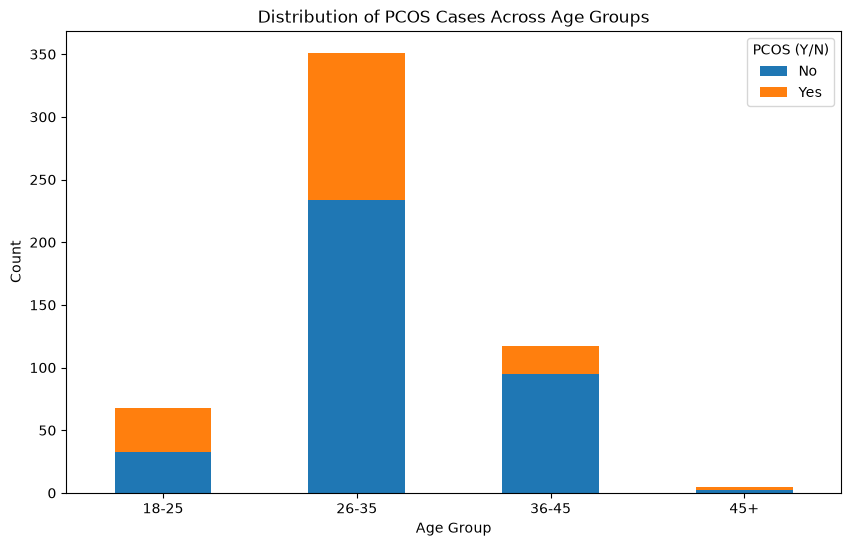

In [22]:
age_group_counts.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Distribution of PCOS Cases Across Age Groups')
plt.xlabel('Age Group')
plt.ylabel('Count')
plt.legend(title='PCOS (Y/N)', loc='upper right', labels=['No', 'Yes'])
plt.xticks(rotation=0)
plt.show()

From the bar graph above, it shows that PCOS majorly affects ladies within the age range of 26-35

#### 2. Distribution analysis for numerical variables

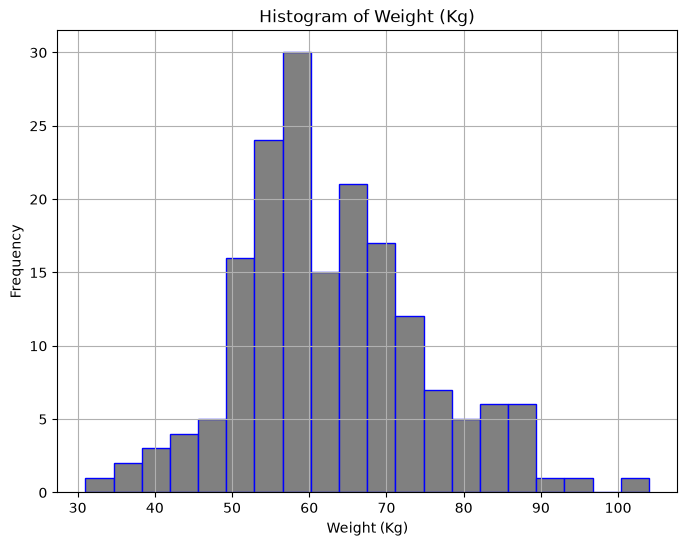

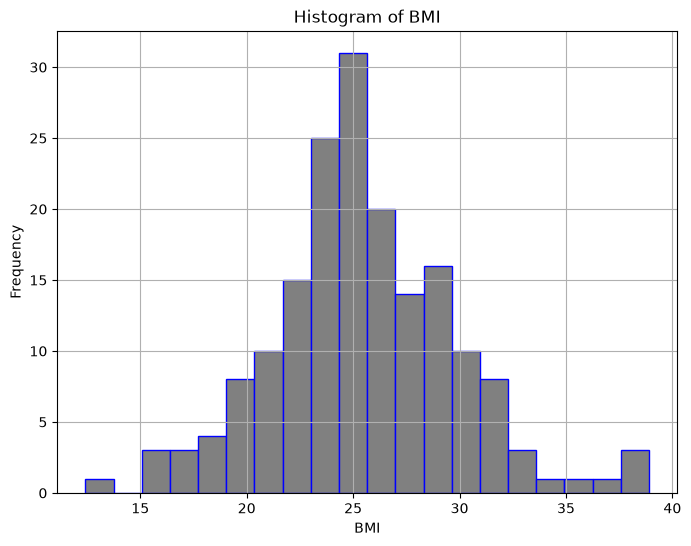

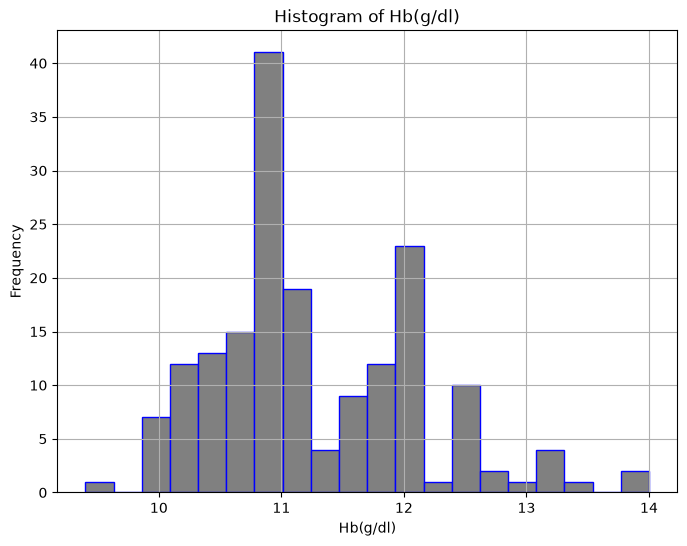

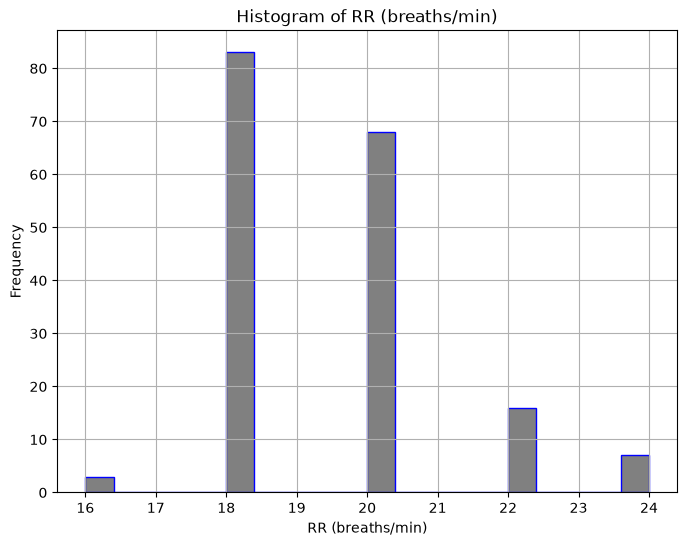

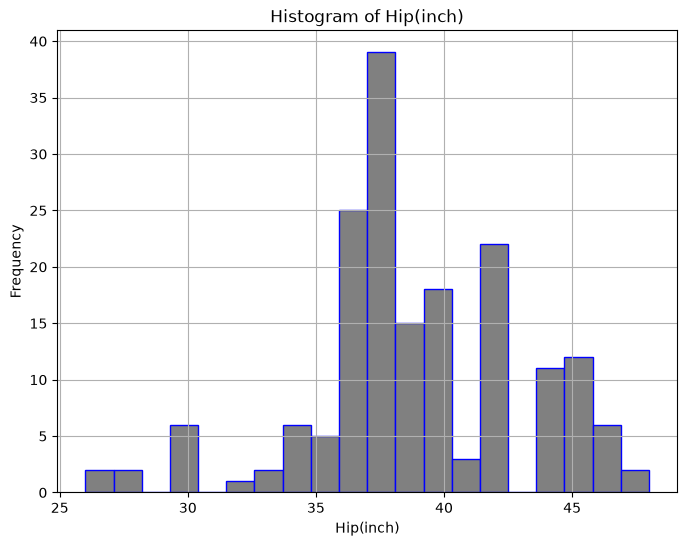

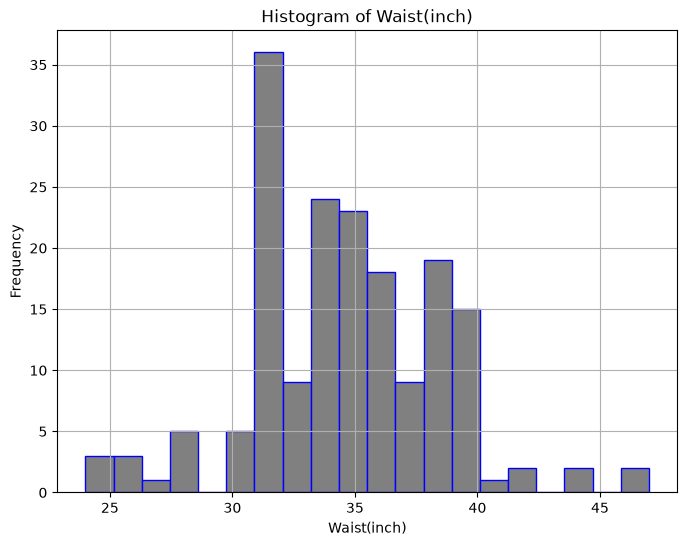

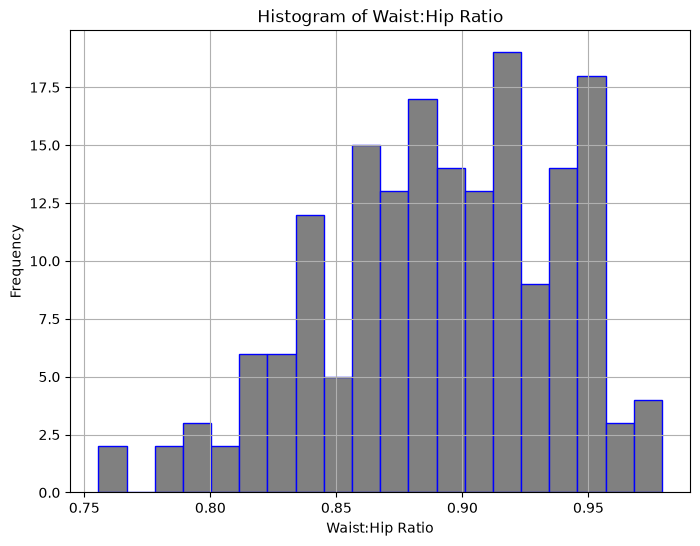

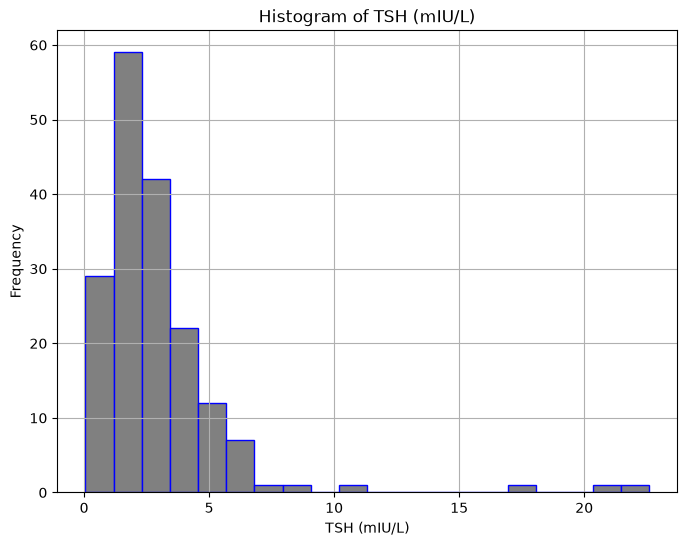

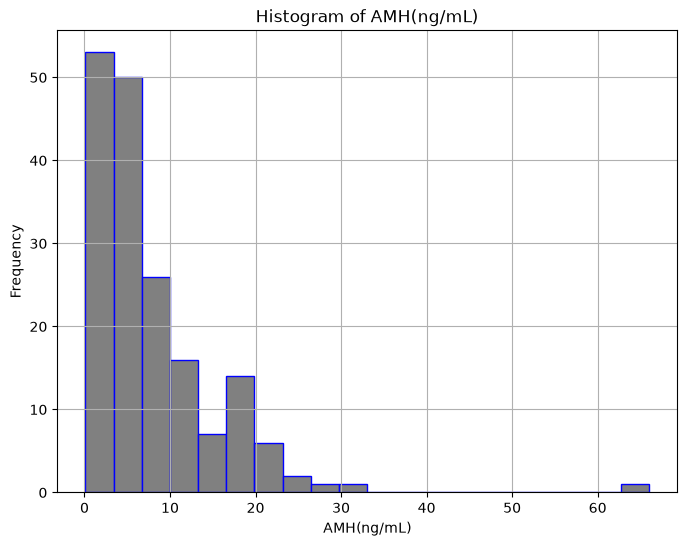

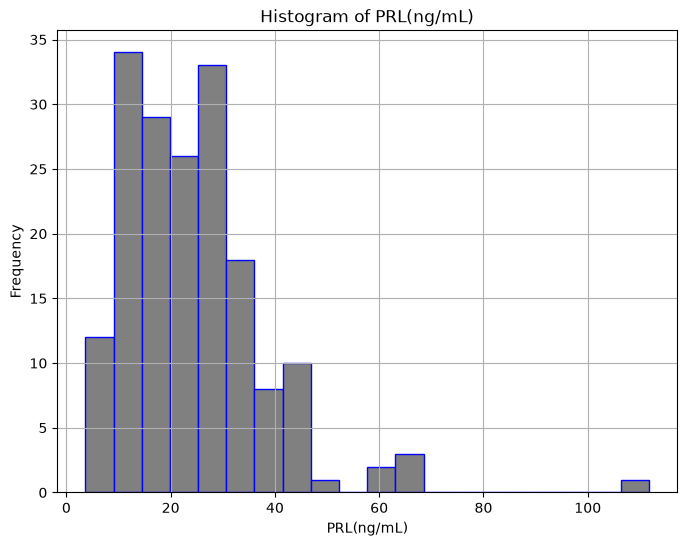

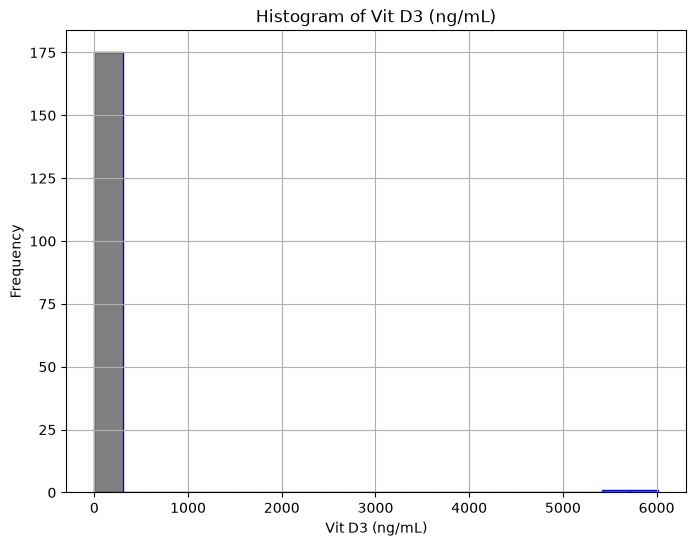

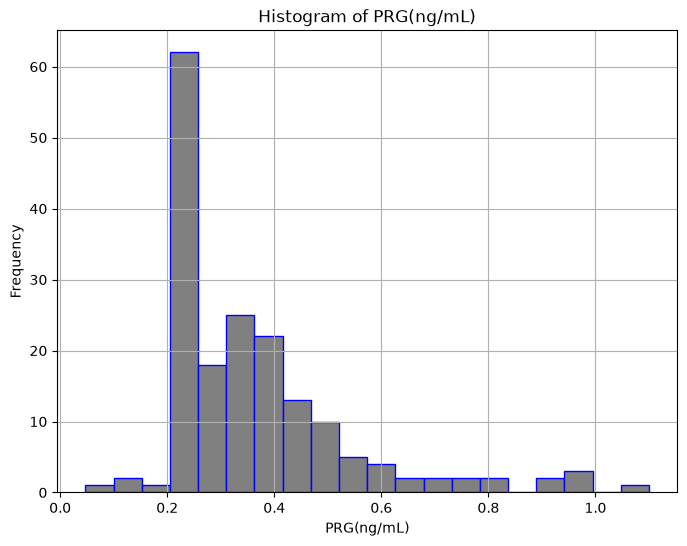

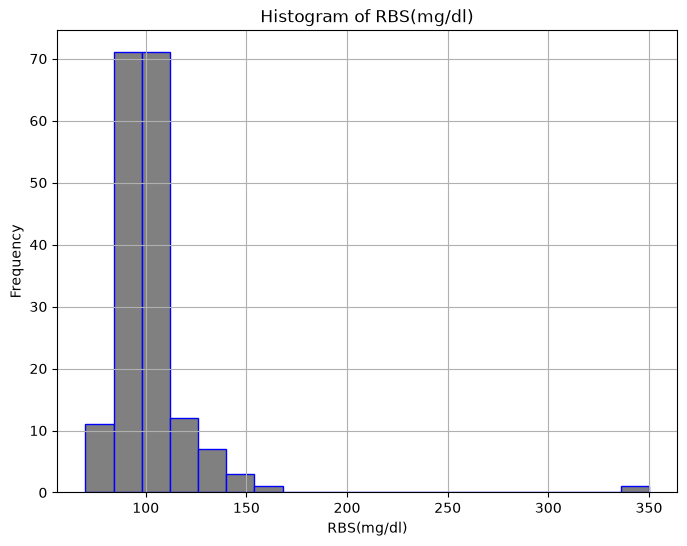

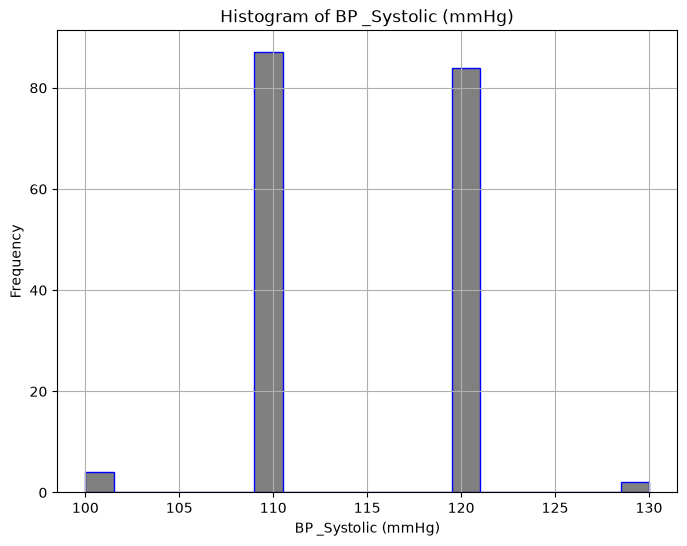

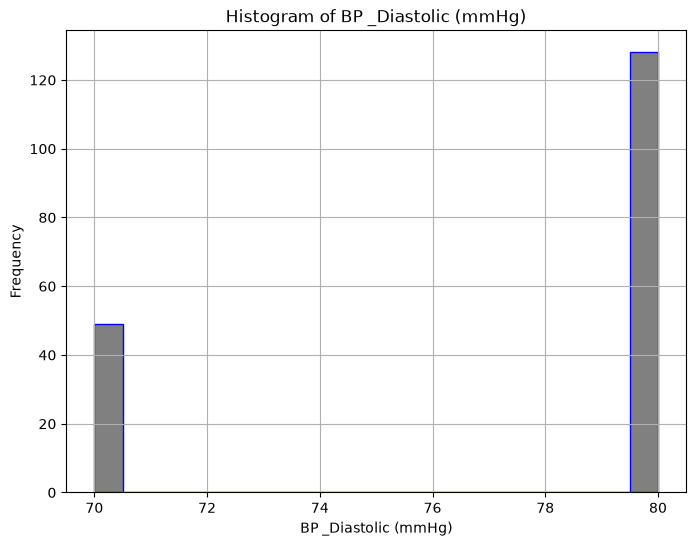

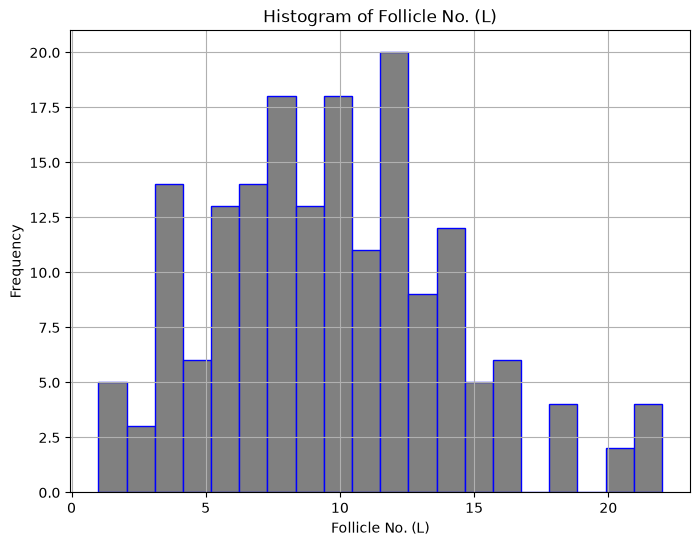

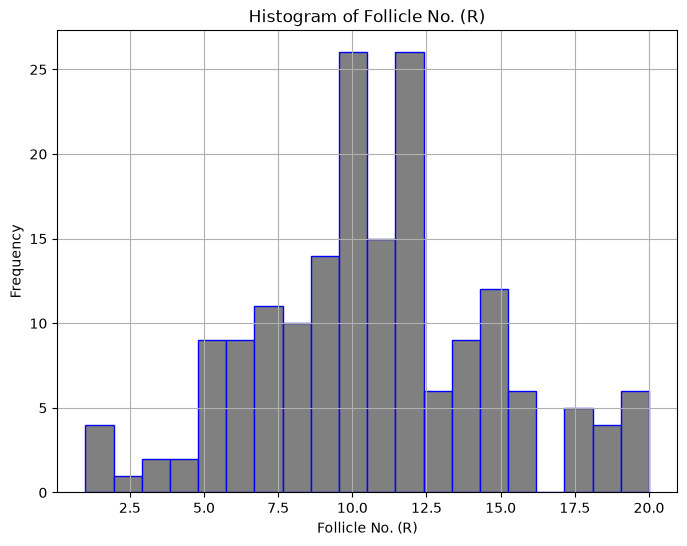

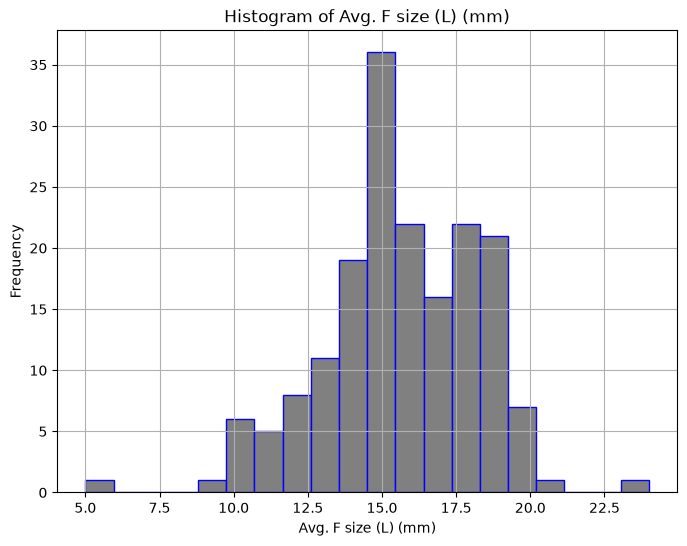

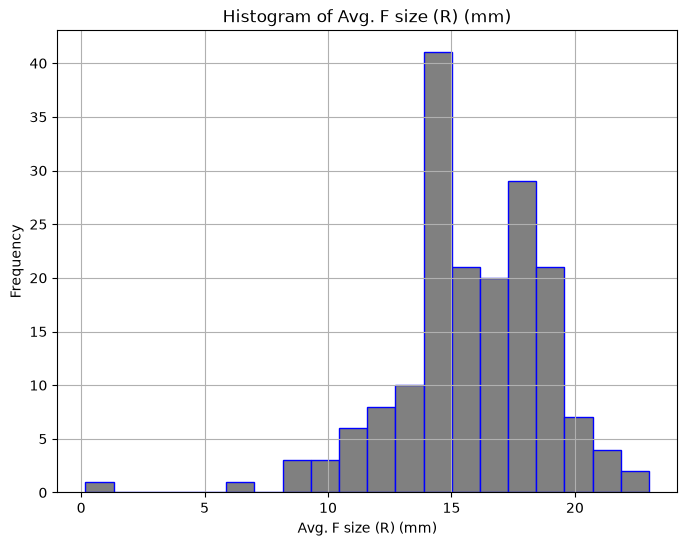

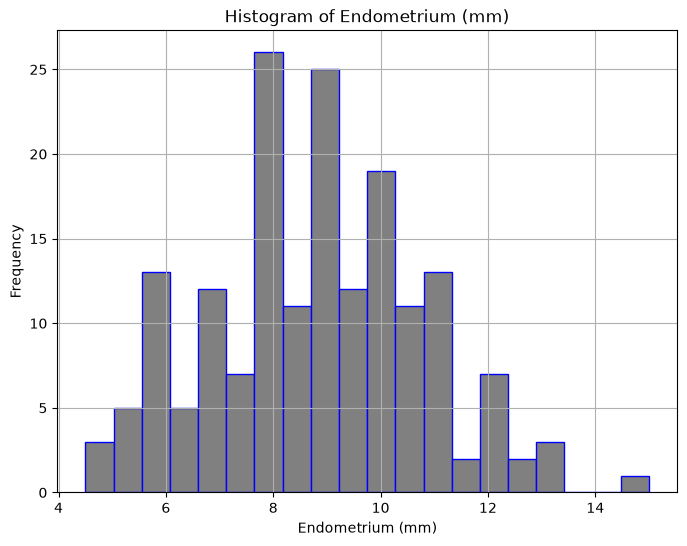

In [23]:
# List of numerical attributes for distribution analysis
numerical_attributes = ['Weight (Kg)', 'BMI', 'Hb(g/dl)','RR (breaths/min)',
                        'Hip(inch)', 'Waist(inch)', 'Waist:Hip Ratio', 'TSH (mIU/L)', 'AMH(ng/mL)', 'PRL(ng/mL)',
                        'Vit D3 (ng/mL)', 'PRG(ng/mL)', 'RBS(mg/dl)', 'BP _Systolic (mmHg)', 'BP _Diastolic (mmHg)',
                        'Follicle No. (L)', 'Follicle No. (R)', 'Avg. F size (L) (mm)', 'Avg. F size (R) (mm)',
                        'Endometrium (mm)']
df_pcos = df[df['PCOS (Y/N)']==1]
# Create histograms for each numerical attribute
for attribute in numerical_attributes:
    plt.figure(figsize=(8, 6))
    plt.hist(df_pcos[attribute], bins=20, color='grey', edgecolor='blue')
    plt.title(f'Histogram of {attribute}')
    plt.xlabel(attribute)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

## Feature Selection

In [24]:
#Select the top 10 features that correlates with target variable the most

top_10 = correlation_with_target[0:11]
print(top_10)

PCOS (Y/N)              1.000000
Follicle No. (R)        0.648327
Follicle No. (L)        0.603346
Skin darkening (Y/N)    0.475733
hair growth(Y/N)        0.464667
Weight gain(Y/N)        0.441047
Cycle(R/I)              0.401644
Fast food (Y/N)         0.377933
Pimples(Y/N)            0.286077
AMH(ng/mL)              0.263863
Weight (Kg)             0.211938
Name: PCOS (Y/N), dtype: float64


In [25]:
df_new = df[['PCOS (Y/N)','Follicle No. (R)','Follicle No. (L)','Skin darkening (Y/N)','hair growth(Y/N)','Weight gain(Y/N)',
             'Cycle(R/I)','Fast food (Y/N)','Pimples(Y/N)','AMH(ng/mL)','Weight (Kg)']]
df_new.head()

,PCOS (Y/N),Follicle No. (R),Follicle No. (L),Skin darkening (Y/N),hair growth(Y/N),Weight gain(Y/N),Cycle(R/I),Fast food (Y/N),Pimples(Y/N),AMH(ng/mL),Weight (Kg)
0,0.0,3.0,3.0,0.0,0.0,0.0,2.0,1.0,0.0,2.07,44.6
1,0.0,5.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.53,65.0
2,1.0,15.0,13.0,0.0,0.0,0.0,2.0,1.0,1.0,6.63,68.8
3,0.0,2.0,2.0,0.0,0.0,0.0,2.0,0.0,0.0,1.22,65.0
4,0.0,4.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,2.26,52.0


Check for correlation using heatmap

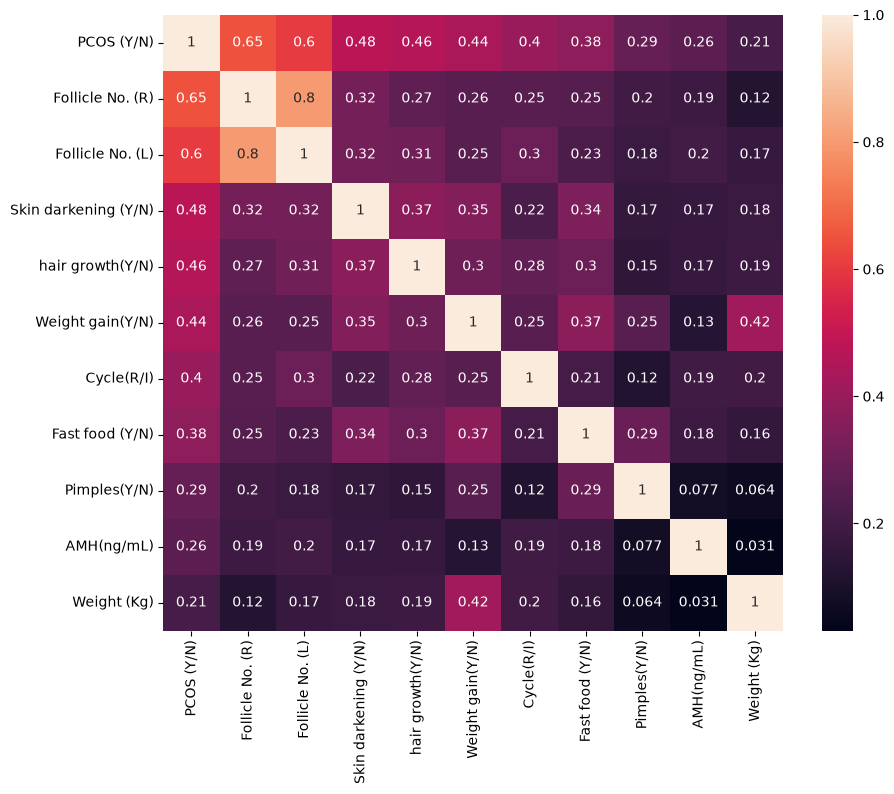

In [26]:
plt.figure(figsize=(10,8))
sns.heatmap(df_new.corr(),annot=True)
plt.show()

Plot value count of 'PCOS(Y/N)' column to calculate relative frequencies of the classes

In [27]:
df_new['PCOS (Y/N)'].value_counts()

PCOS (Y/N)
0.0    364
1.0    177
Name: count, dtype: int64

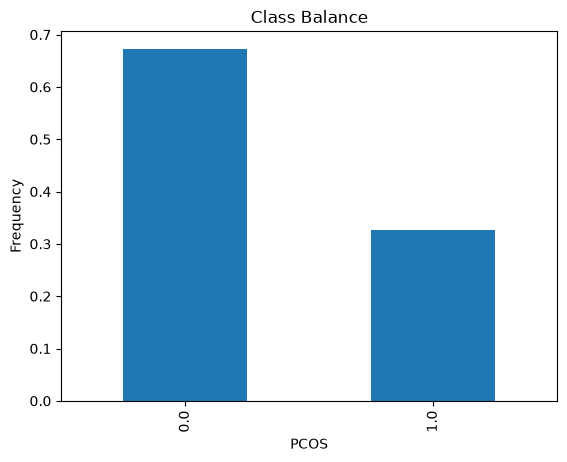

In [28]:
df_new['PCOS (Y/N)'].value_counts(normalize=True).plot(
        kind = 'bar', xlabel = 'PCOS', ylabel='Frequency', title='Class Balance'
);

In [29]:
df_new=df_new.dropna()
df_new.isna().sum()


PCOS (Y/N)              0
Follicle No. (R)        0
Follicle No. (L)        0
Skin darkening (Y/N)    0
hair growth(Y/N)        0
Weight gain(Y/N)        0
Cycle(R/I)              0
Fast food (Y/N)         0
Pimples(Y/N)            0
AMH(ng/mL)              0
Weight (Kg)             0
dtype: int64

## PCOS detection using Logistic Regression

### Split

Creating feature matrix and target vector using train_test_split to split the data into train set and test set

In [30]:
df_new.shape

(539, 11)

In [31]:
target = 'PCOS (Y/N)'
X = df_new.drop(columns = target)
y = df_new[target]

In [32]:
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size = 0.2, random_state=42)

print('X_train shape', X_train.shape)
print('X_test shape', X_test.shape)
print('y_train shape', y_train.shape)
print('y_test shape', y_test.shape)

X_train shape (431, 10)
X_test shape (108, 10)
y_train shape (431,)
y_test shape (108,)


## Build Model

### Baseline

Check the baseline accuracy score for model

In [33]:
acc_baseline=y_train.value_counts(normalize=True).max()
print('Baseline accuracy', round(acc_baseline,2))

Baseline accuracy 0.66


### Iterate

Create model using Logistic Regression predictor

In [34]:
lr = LogisticRegression(max_iter=1000)

In [35]:
lr.fit(X_train,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

### Evaluation

Check the training and test accuracy score, the confusion matrix and and Classification report

In [36]:
acc_train = accuracy_score(y_train, lr.predict(X_train))
acc_test = lr.score(X_test,y_test)
print('Training Accuracy',round(acc_train, 2))
print('Test Accuracy', round(acc_test, 2))

Training Accuracy 0.92
Test Accuracy 0.89


In [37]:
y_pred = lr.predict(X_test)

In [38]:
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print('Confusion Matrix')
print(conf_matrix)
print('Classification Report')
print(class_report)

Confusion Matrix
[[74  5]
 [ 7 22]]
Classification Report
              precision    recall  f1-score   support

         0.0       0.91      0.94      0.93        79
         1.0       0.81      0.76      0.79        29

    accuracy                           0.89       108
   macro avg       0.86      0.85      0.86       108
weighted avg       0.89      0.89      0.89       108



Conclusion for Logistic Regression :

The model performs well for class 0 (the negative class) with high precision (91%), recall (94%), and F1-score (93%). The model performs reasonably well for class 1 (the positive class) with a decent precision (81%) and F1-score (79%), but the recall (76%) is slightly lower, indicating that some positive samples are being misclassified as negative.